In [3]:
!pip install torch
!pip install matplotlib
!pip install numpy

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cpu")

In [2]:
m1 = 291
m2 = 582
c1 = 13687
c2 = 9952
k1 = 45929
k2 = 40731
A = 0
N = nn.Sequential(nn.Linear(1, 50), nn.Sigmoid(), nn.Linear(50,1, bias=False))
x1 = lambda t: A + t*N(t)
x2 = lambda t: A + t*N(t)

def loss(t):
    t.requires_grad = True
    outputs1 = x1(t)
    outputs2 = x2(t)
    x1_t = torch.autograd.grad(outputs1, t, grad_outputs=torch.ones_like(outputs1), create_graph=True)[0]
    x1_tt = torch.autograd.grad(outputs1, t, grad_outputs=torch.ones_like(x1_t), create_graph=True)[0]
    x2_t = torch.autograd.grad(outputs2, t, grad_outputs=torch.ones_like(outputs2), create_graph=True)[0]
    x2_tt = torch.autograd.grad(outputs2, t, grad_outputs=torch.ones_like(x2_t), create_graph=True)[0]
    return torch.mean(((m1*x1_tt + (c1+c2)*x1_t + (k1+k2)*outputs1 - c2*x2_t - k2*outputs2) ** 2)+((m2*x2_tt + c2*x2_t - c2*x1_t + k2*outputs2 - k2*outputs1) ** 2))

In [3]:
optimizer = torch.optim.LBFGS(N.parameters())

# The collocation points used by Lagaris
t = torch.Tensor(np.linspace(0, 2, 100)[:, None])

# Run the optimizer
def closure1():
    optimizer.zero_grad()
    l = loss1(t)
    l.backward()
    return l
    
for i in range(10):
    optimizer.step(closure1)

xx = np.linspace(0, 0.3, 100)[:, None]

with torch.no_grad():
    uu = x1(torch.Tensor(xx)).numpy()
    
    
optimizer = torch.optim.LBFGS(N.parameters())

# The collocation points used by Lagaris
x = torch.Tensor(np.linspace(0, 2, 100)[:, None])

# Run the optimizer
def closure2():
    optimizer.zero_grad()
    l = loss2(x)
    l.backward()
    return l
    
for i in range(10):
    optimizer.step(closure2)

xx = np.linspace(0, 0.3, 100)[:, None]

with torch.no_grad():
    vv = x2(torch.Tensor(xx)).numpy()


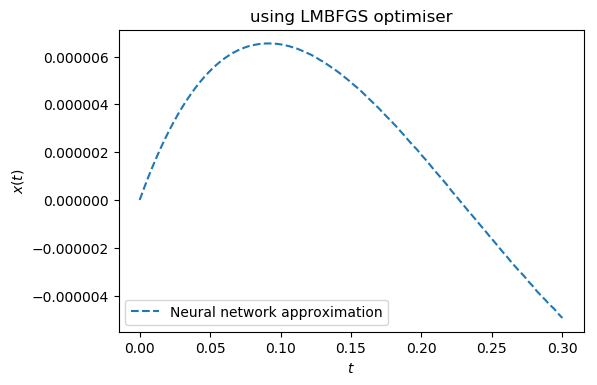

In [4]:
fig, ax = plt.subplots(dpi=100)
ax.plot(xx, (uu+vv), '--', label='Neural network approximation')
ax.set_xlabel('$t$')
ax.set_ylabel('$x(t)$')
plt.title('using LMBFGS optimiser')
plt.legend(loc='best');

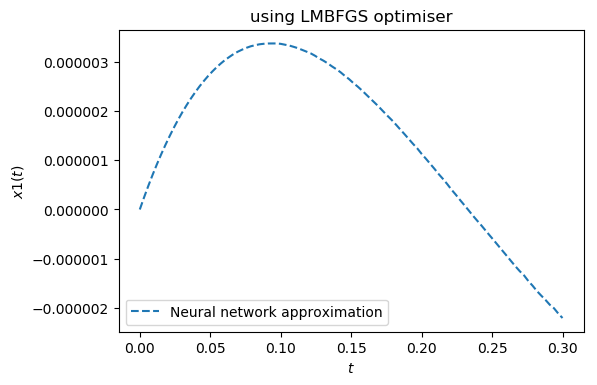

In [5]:
fig, ax = plt.subplots(dpi=100)
ax.plot(xx, (uu), '--', label='Neural network approximation')
ax.set_xlabel('$t$')
ax.set_ylabel('$x1(t)$')
plt.title('using LMBFGS optimiser')
plt.legend(loc='best');

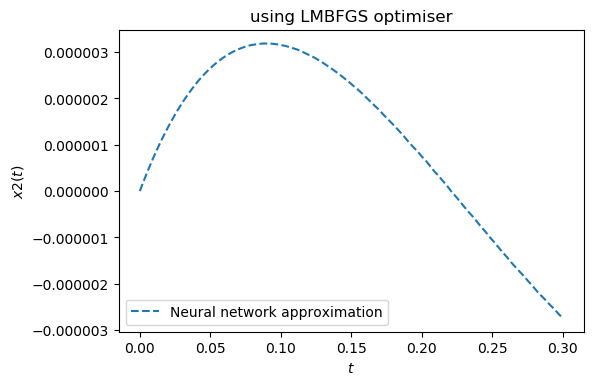

In [6]:
fig, ax = plt.subplots(dpi=100)
ax.plot(xx, (vv), '--', label='Neural network approximation')
ax.set_xlabel('$t$')
ax.set_ylabel('$x2(t)$')
plt.title('using LMBFGS optimiser')
plt.legend(loc='best');

In [7]:
!pip install galibrate
from galibrate.sampled_parameter import SampledParameter
from galibrate import GAO

D:\Anaconda3\lib\site-packages\galibrate\gao.py:10: RuntimeWarning: ------Running GAO with numba optimization.------
  warnings.warn("------Running GAO with numba optimization.------", RuntimeWarning)
